In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
pd.set_option("display.max_columns", None)

In [16]:
sns.set_style("whitegrid")

In [18]:
df = pd.read_csv("C:/Users/mmsin/OneDrive/Desktop/Python Project/project-folder/german_credit_data.csv")

In [20]:
df.shape

(1000, 11)

In [22]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df.dropna().reset_index(drop=True)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [24]:
df.drop(columns = 'Unnamed: 0', inplace = True)

In [25]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Credit amount'}>],
       [<Axes: title={'center': 'Duration'}>, <Axes: >]], dtype=object)

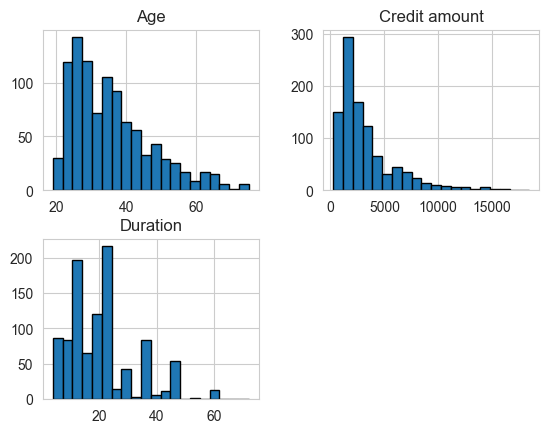

In [26]:
df[["Age", "Credit amount", "Duration"]].hist(bins = 20, edgecolor = "black")

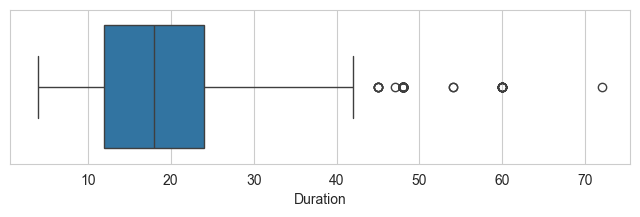

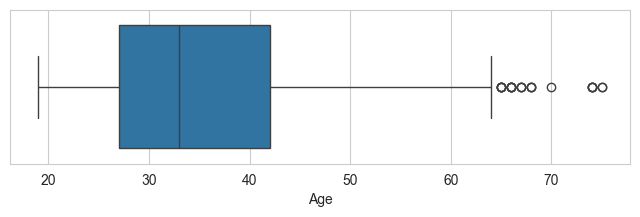

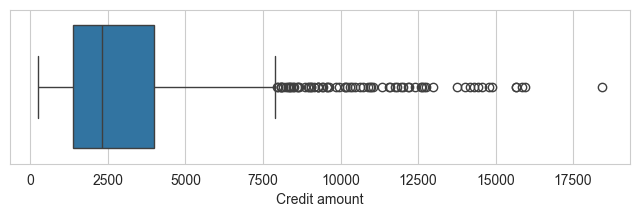

In [27]:
for col in ['Duration', 'Age', 'Credit amount']:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.show()

In [28]:
categorical_cols = ["Sex", "Job","Housing","Saving accounts","Checking account","Purpose"]

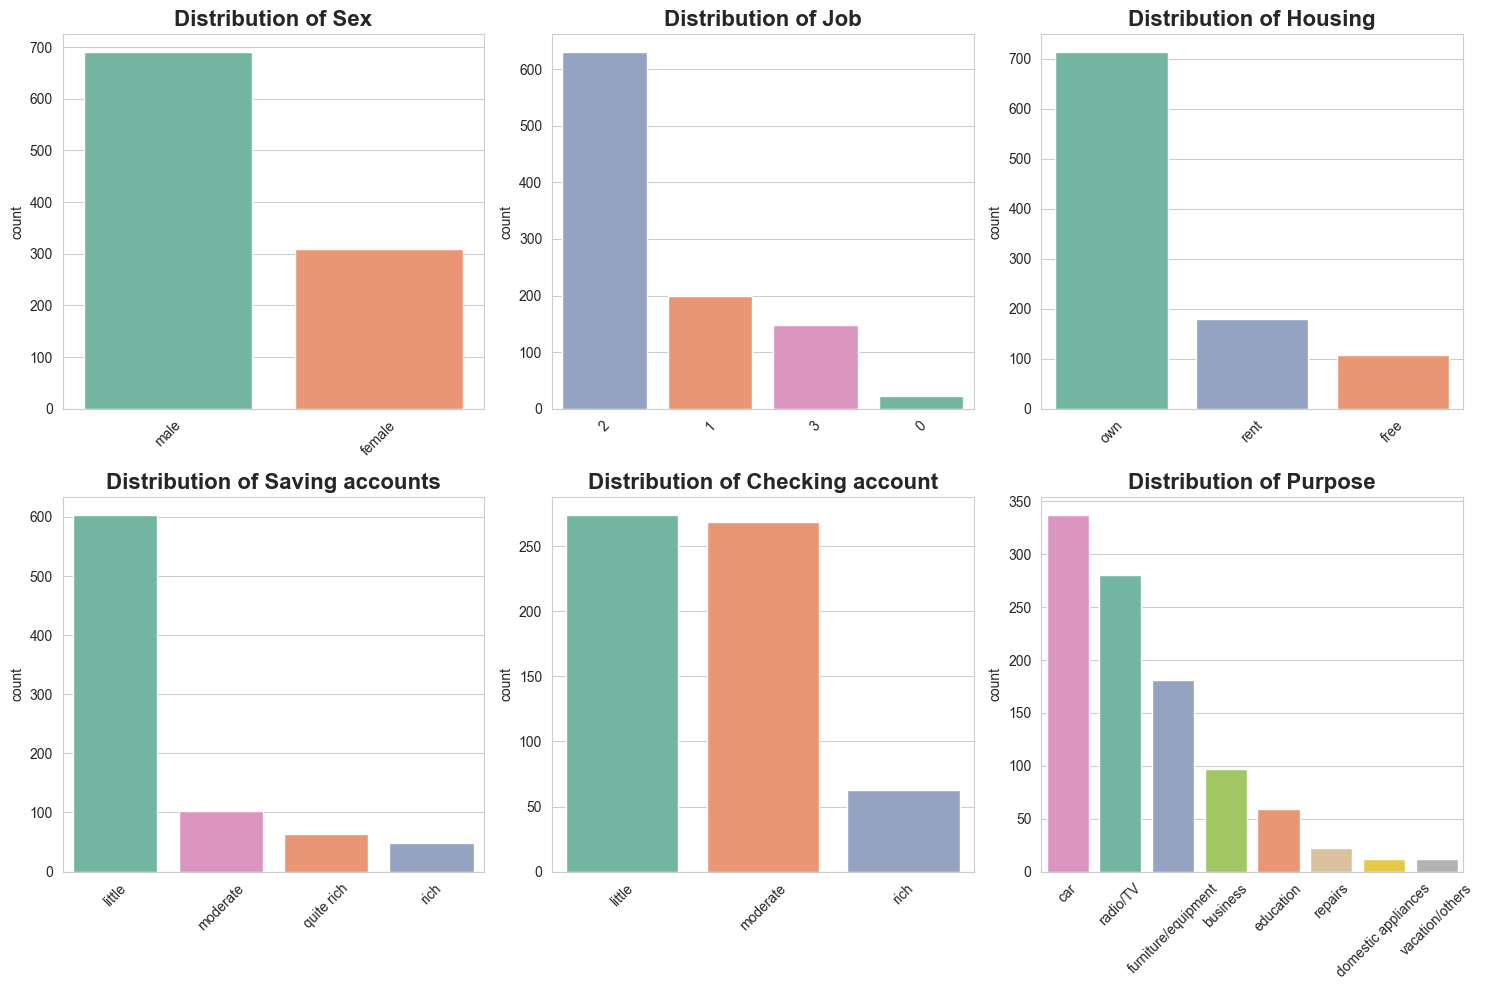

In [29]:
categorical_cols = ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]

plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1)
    
    
    sns.countplot(data=df, x=col, hue=col, palette="Set2", legend=False, 
                  order=df[col].value_counts().index)
    
    plt.title(f"Distribution of {col}", fontsize=16, fontweight='bold')
    plt.xticks(rotation=45)
    plt.xlabel("") 
plt.tight_layout()
plt.show()

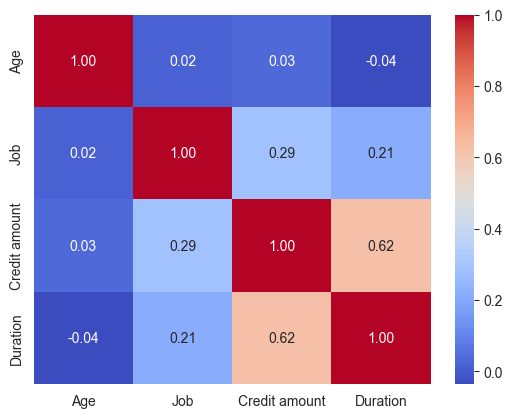

In [30]:
corr = df[["Age", "Job", "Credit amount", "Duration"]].corr()
sns.heatmap(corr, annot=True, cmap = "coolwarm", fmt=".2f")
plt.show()

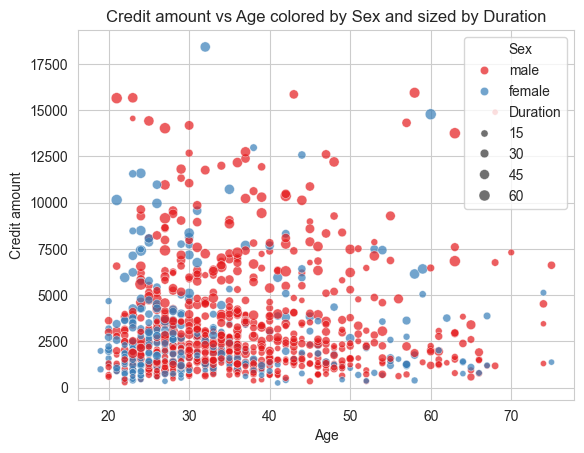

In [31]:
sns.scatterplot(data=df, x="Age", y="Credit amount", hue="Sex", size="Duration", alpha=.7, palette="Set1")
plt.title("Credit amount vs Age colored by Sex and sized by Duration")
plt.show()

In [32]:
df["Risk"].value_counts(normalize=True)*100

Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64

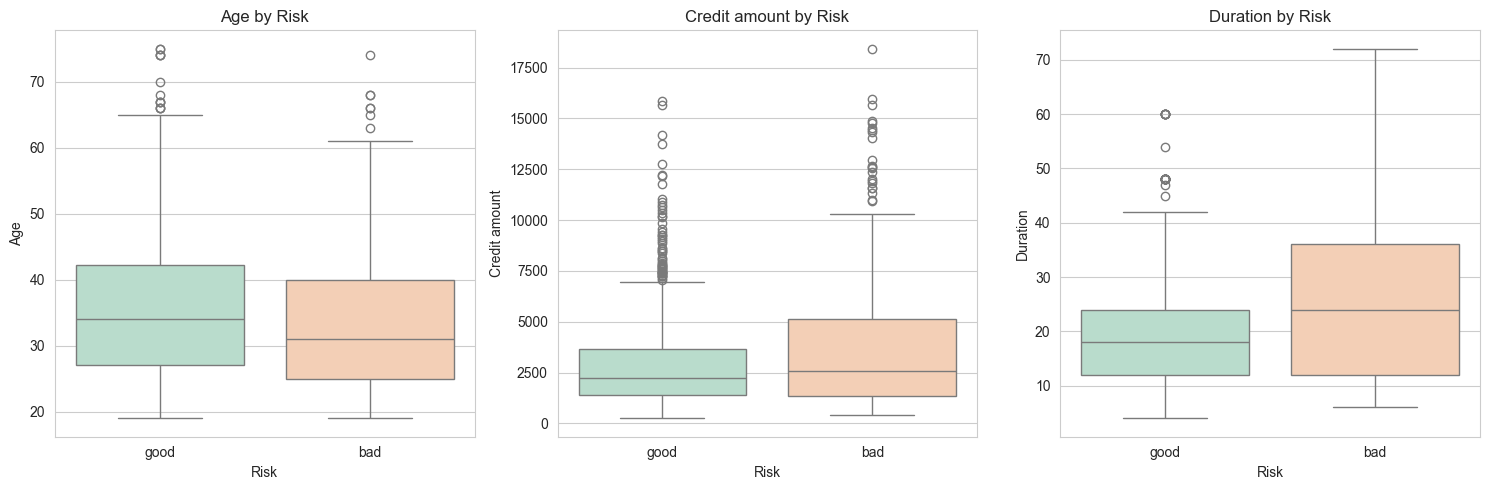

In [33]:
plt.figure(figsize=(15, 5)) 


for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i + 1)
    
    
    sns.boxplot(data=df, x="Risk", y=col, hue="Risk", palette="Pastel2", legend=False)
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

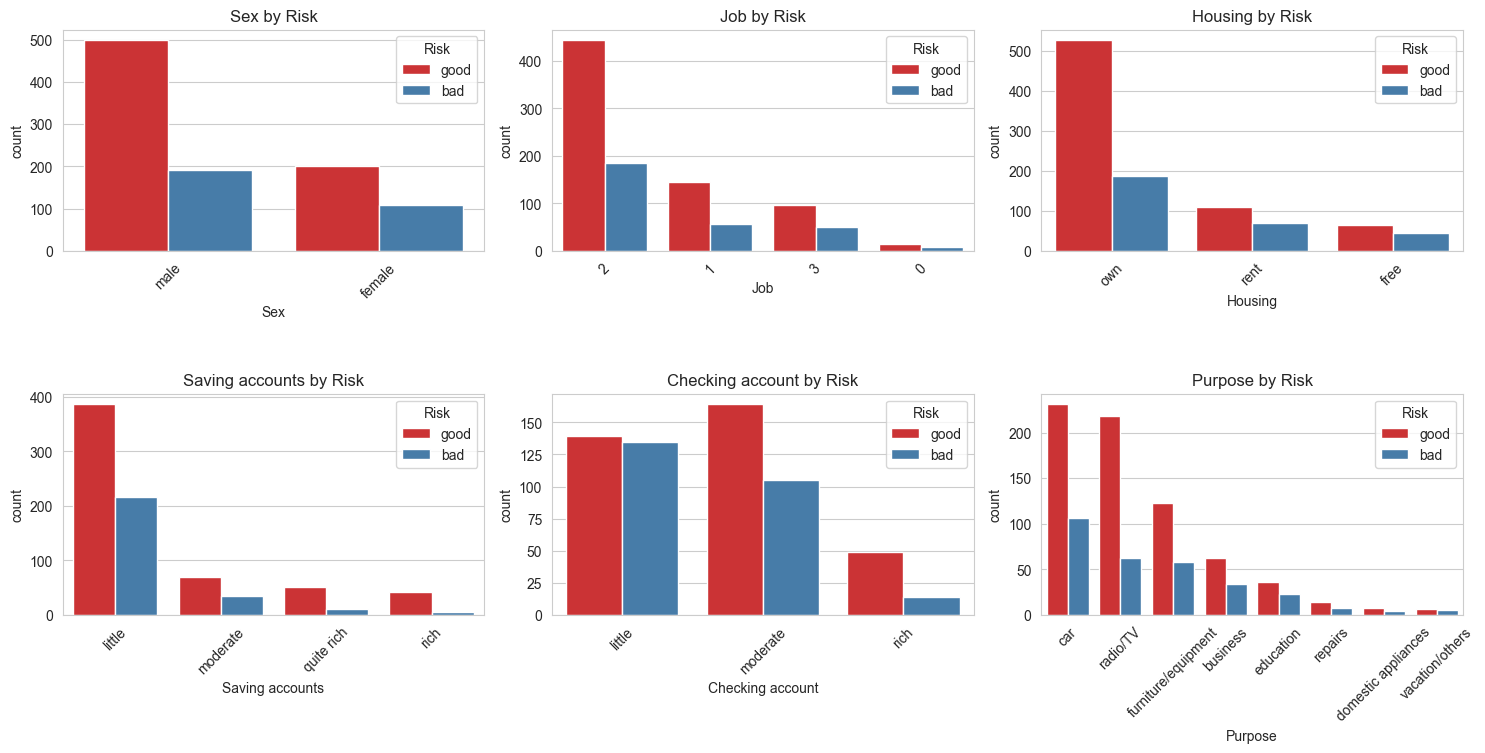

In [34]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=df, x=col, hue="Risk", palette="Set1", 
                  order=df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [35]:
features = ["Age","Sex","Job","Checking account","Saving accounts","Credit amount","Duration","Housing"]

In [36]:
target = "Risk"

In [37]:
df_model = df[features + [target]].copy()
df_model.head()

,Age,Sex,Job,Checking account,Saving accounts,Credit amount,Duration,Housing,Risk
0,67,male,2,little,NaN,1169,6,own,good
1,22,female,2,moderate,little,5951,48,own,bad
2,49,male,1,NaN,little,2096,12,own,good
3,45,male,2,little,little,7882,42,free,good
4,53,male,2,little,little,4870,24,free,bad


In [39]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [41]:
cat_cols = df_model.select_dtypes(include="object").columns.drop("Risk")
cat_cols

Index(['Sex', 'Checking account', 'Saving accounts', 'Housing'], dtype='object')

In [44]:
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_encoder.plk")

In [45]:
le_target = LabelEncoder()

In [46]:
target

'Risk'

In [47]:
df_model[target] = le_target.fit_transform(df_model[target])
df_model[target]

0      1
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: Risk, Length: 1000, dtype: int64

In [48]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [49]:
df_model.head()

,Age,Sex,Job,Checking account,Saving accounts,Credit amount,Duration,Housing,Risk
0,67,1,2,0,4,1169,6,1,1
1,22,0,2,1,0,5951,48,1,0
2,49,1,1,3,0,2096,12,1,1
3,45,1,2,0,0,7882,42,0,1
4,53,1,2,0,0,4870,24,0,0


In [50]:
from sklearn.model_selection import train_test_split
x = df_model.drop(target, axis = 1)
y = df_model[target]

In [51]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify = y, random_state = 1)

In [52]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [55]:
def train_model(model, param_grid, x_train, y_train, x_test, y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_
    
    y_pred = best_model.predict(x_test) 
    acc = accuracy_score(y_test, y_pred)
    
    return best_model, acc, grid.best_params_

In [56]:
dt = DecisionTreeClassifier(random_state =1, class_weight = "balanced")
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
    

In [57]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, x_train, y_train, x_test, y_test)

In [58]:
print("Decision Tree Accuracy", acc_dt)
print("Best Parameter", params_dt)

Decision Tree Accuracy 0.705
Best Parameter {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [59]:
rf = RandomForestClassifier(random_state =1, class_weight = "balanced", n_jobs=-1)

In [60]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [61]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, x_train, y_train, x_test, y_test)

In [62]:
print("Random Forest Accuracy", acc_rf)
print("Parameters", params_rf)

Random Forest Accuracy 0.765
Parameters {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [63]:
xgb = XGBClassifier(random_state = 1, scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),  eval_metric = "logloss")

In [64]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate" : [0.01, 0.1, 0.2],
    "subsample": [0.7,1],
    "colsample_bytree": [0.7,1]
}

In [65]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, x_train, y_train, x_test, y_test)

In [66]:
print("XGB Accuracy", acc_xgb)
print("Best parameters:", params_xgb)

XGB Accuracy 0.75
Best parameters: {'colsample_bytree': 1, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.7}


In [73]:
joblib.dump(best_rf, "Random_Forest_credit_model.pkl")

['Random_Forest_credit_model.pkl']

In [75]:
print(best_rf.feature_names_in_)

['Age' 'Sex' 'Job' 'Checking account' 'Saving accounts' 'Credit amount'
 'Duration' 'Housing']


In [77]:
# Replace 'best_rf' with the actual name of your model variable
print(list(best_rf.feature_names_in_))

['Age', 'Sex', 'Job', 'Checking account', 'Saving accounts', 'Credit amount', 'Duration', 'Housing']
